This notebook contains the code to make the following plots:

1) Mass-Light Shape Components per band
2) Astrometric Comparison with Gaia DR2
3) Fermat Potential Precision vs. AB Lensed Arc Mag

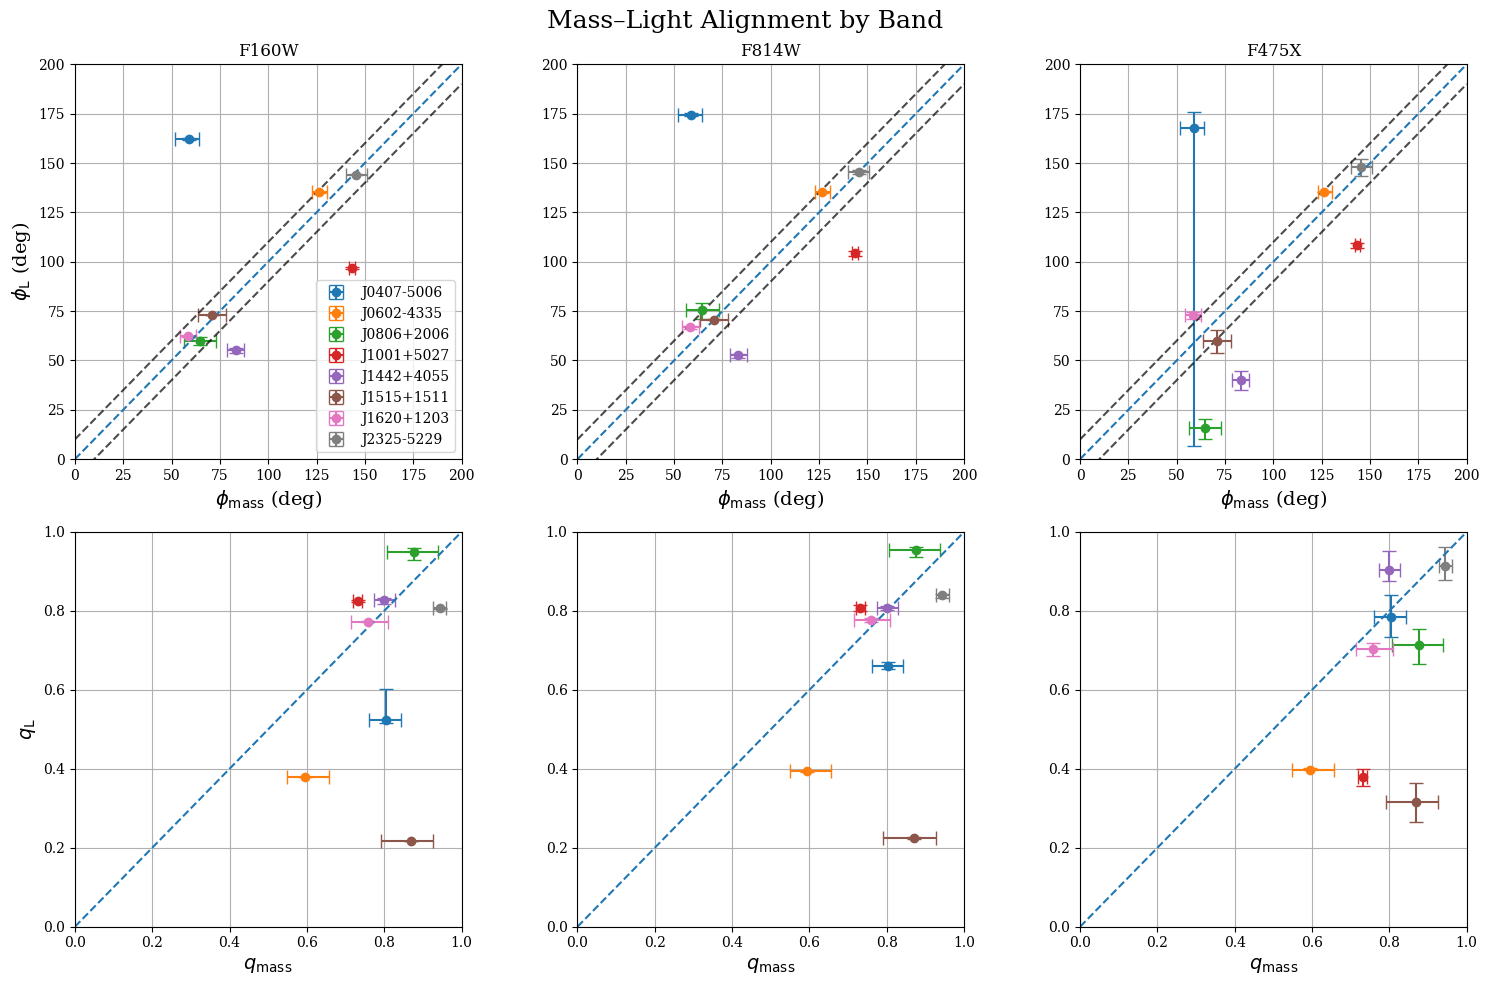

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import h5py
from lenstronomy.Util import param_util
import matplotlib as mpl

mpl.rcParams['font.family'] = 'serif'


class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'LikelihoodAddition':
            class LikelihoodAddition:
                pass
            return LikelihoodAddition
        return super().find_class(module, name)


def get_phi_q_chain(samples, e1_name, e2_name, param_mcmc):
    i1 = param_mcmc.index(e1_name)
    i2 = param_mcmc.index(e2_name)

    e1_chain = samples[:, i1]
    e2_chain = samples[:, i2]

    phi, q = param_util.ellipticity2phi_q(e1_chain, e2_chain)
    phi = (phi * 180 / np.pi) % 180
    return phi, q


def median_and_err(chain):
    med = np.percentile(chain, 50)
    lo  = med - np.percentile(chain, 16)
    up  = np.percentile(chain, 84) - med
    return med, lo, up


names = [
    'J0407-5006',
    'J0602-4335',
    'J0806+2006', 
    'J1001+5027',
    'J1442+4055', 
    'J1515+1511', 
    'J1620+1203', 
    'J2325-5229'
]

# column index per filter
filters = {
    "F160W": 0,
    "F814W": 1,
    "F475X": 2,
}

capsize = 5
fontsize = 14

fig, ax = plt.subplots(2, 3, figsize=(15, 10))
xs = np.linspace(0, 1)
xs_phi = np.linspace(0, 200)

for name in names:

    # load joint MCMC (mass)
    joint_file = f'../joint_modeling/{name}/{name}_joint.pkl'
    with open(joint_file, "rb") as f:
        loaded_data = CustomUnpickler(f).load()

    sampler_type, samples, param_mcmc, dist_mcmc = loaded_data["chain_list"][-1]

    phi_mass, q_mass = get_phi_q_chain(
        samples, "e1_lens0", "e2_lens0", param_mcmc
    )

    phi_m, phi_m_lo, phi_m_up = median_and_err(phi_mass)
    q_m,   q_m_lo,   q_m_up   = median_and_err(q_mass)

    # load light ellipticity
    hdf5_file = f'../joint_modeling/{name}/{name}_photometry.hdf5'

    with h5py.File(hdf5_file, "r") as f:

        for filt, j in filters.items():

            phi_L = f[filt]["ellipticity"]["phi_samples"][()]
            q_L   = f[filt]["ellipticity"]["q_samples"][()]

            phi_L_m, phi_L_lo, phi_L_up = median_and_err(phi_L)
            q_L_m,   q_L_lo,   q_L_up   = median_and_err(q_L)

            # phi alignment
            ax[0, j].errorbar(
                phi_m, phi_L_m,
                xerr=[[phi_m_lo], [phi_m_up]],
                yerr=[[phi_L_lo], [phi_L_up]],
                fmt='o', capsize=capsize,
                label=name if filt == "F160W" else None
            )

            # q alignment
            ax[1, j].errorbar(
                q_m, q_L_m,
                xerr=[[q_m_lo], [q_m_up]],
                yerr=[[q_L_lo], [q_L_up]],
                fmt='o', capsize=capsize
            )

# formatting
for j in range(3):
    ax[0, j].plot(xs_phi, xs_phi, ls='--', color='tab:blue')
    ax[0, j].plot(xs_phi, xs_phi - 10, ls='--', color='black', alpha=0.7)
    ax[0, j].plot(xs_phi, xs_phi + 10, ls='--', color='black', alpha=0.7)
    ax[0, j].set_xlim(0, 200)
    ax[0, j].set_ylim(0, 200)
    ax[0, j].grid()

    ax[1, j].plot(xs, xs, ls='--', color='tab:blue')
    ax[1, j].set_xlim(0, 1)
    ax[1, j].set_ylim(0, 1)
    ax[1, j].grid()

ax[0, 0].set_title('F160W')
ax[0, 1].set_title('F814W')
ax[0, 2].set_title('F475X')

ax[0, 0].set_ylabel(r'$\phi_{\mathrm{L}}$ (deg)', fontsize=fontsize)
ax[1, 0].set_ylabel(r'$q_{\mathrm{L}}$', fontsize=fontsize)

for j in range(3):
    ax[1, j].set_xlabel(r'$q_{\mathrm{mass}}$', fontsize=fontsize)
    ax[0, j].set_xlabel(r'$\phi_{\mathrm{mass}}$ (deg)', fontsize=fontsize)

ax[0, 0].legend()

fig.suptitle('Mass–Light Alignment by Band', fontsize = 18)
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
#plt.savefig('mass-light.png')
plt.show()


RMS Difference from Gaia DR2: 3.6241401827845907 mas


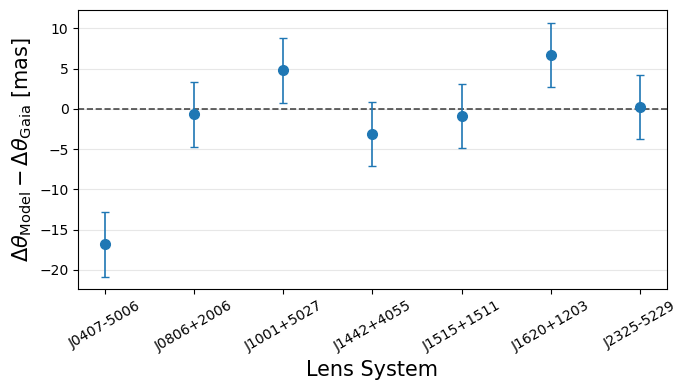

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Lens systems
names = [
    'J0407-5006',
    'J0806+2006',
    'J1001+5027',
    'J1442+4055',
    'J1515+1511',
    'J1620+1203',
    'J2325-5229'
]

# Gaia DR2 separations
gaia_dict = {
    'J0407-5006': 1.721,
    'J0806+2006': 1.485,
    'J1001+5027': 2.927,
    'J1442+4055': 2.132,
    'J1515+1511': 2.009,
    'J1620+1203': 2.806,
    'J2325-5229': 2.819
}


class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'LikelihoodAddition':
            class LikelihoodAddition:
                pass
            return LikelihoodAddition
        return super().find_class(module, name)


def average(difs, type='mean'):
    """compute mean or RMS difference given list of differences"""
    sums = 0
    if type == 'mean':
        for i in range(len(difs)):
            sums += difs[i]
            ans = sums / len(difs)
    elif type == 'rms':
        for i in range(len(difs)):
            sums += difs[i]**2
        ans = np.sqrt(sums / len(difs))
        
    return ans

model_seps = []
model_errs = []
gaia_seps = []

# Loop over systems
for name in names:
    filename = f"../joint_modeling/{name}/{name}_joint.pkl"

    with open(filename, "rb") as f:
        loaded_data = CustomUnpickler(f).load()

    kwargs_result = loaded_data["kwargs_result"]

    # lens center
    ra_lens = kwargs_result['kwargs_lens'][0]['center_x']
    dec_lens = kwargs_result['kwargs_lens'][0]['center_y']

    # image positions relative to lens
    ra_images = np.array(kwargs_result['kwargs_ps'][0]['ra_image']) - ra_lens
    dec_images = np.array(kwargs_result['kwargs_ps'][0]['dec_image']) - dec_lens

    # separation between first two images
    dx = ra_images[0] - ra_images[1]
    dy = dec_images[0] - dec_images[1]
    image_sep = np.sqrt(dx**2 + dy**2)   # arcsec

    model_seps.append(image_sep)

    # 4 mas HST modeling uncertainty
    model_errs.append(0.004)

    # Gaia separation
    gaia_seps.append(gaia_dict[name])


model_seps = np.array(model_seps)
model_errs = np.array(model_errs)
gaia_seps = np.array(gaia_seps)

# Residuals: model − Gaia
diff_seps = (model_seps - gaia_seps) * 1000   # mas
model_errs_mas = model_errs * 1000            # mas

x = np.arange(len(names))

plt.figure(figsize=(7, 4))

# zero reference line
plt.axhline(
    0.0,
    color='k',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7
)

# residual plot
plt.errorbar(
    x,
    diff_seps,
    yerr=model_errs_mas,
    fmt='o',
    markersize=7,
    elinewidth=1.2,
    capsize=3
)

plt.xticks(x, names, rotation=30)
plt.xlabel('Lens System', fontsize = 15)
plt.ylabel(r'$\Delta\theta_{\rm Model} - \Delta\theta_{\rm Gaia}$ [mas]', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# exclude J0407 as outlier
print(f'RMS Difference from Gaia DR2: {average(diff_seps[1:], type='rms')} mas')

#plt.savefig('hst_v_gaia.png')
plt.show()


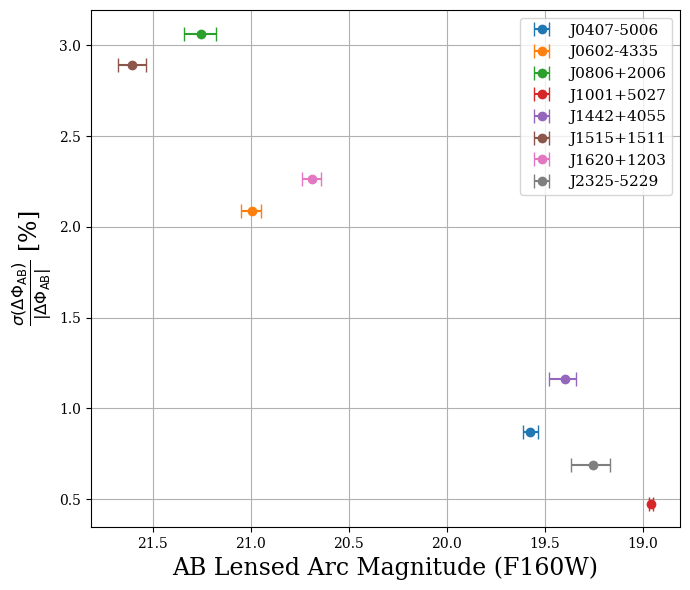

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import h5py
from lenstronomy.Util import param_util
import matplotlib as mpl

mpl.rcParams['font.family'] = 'serif'

class CustomUnpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if name == 'LikelihoodAddition':
            class LikelihoodAddition:
                pass
            return LikelihoodAddition
        return super().find_class(module, name)


def get_median_and_uncertainties(samples):
    median = np.percentile(samples, 50)
    lower = median - np.percentile(samples, 16)
    upper = np.percentile(samples, 84) - median
    return median, lower, upper


names = [
    'J0407-5006',
    'J0602-4335',
    'J0806+2006', 
    'J1001+5027',
    'J1442+4055', 
    'J1515+1511', 
    'J1620+1203', 
    'J2325-5229'
]

capsize = 5
fontsize = 17

fig, ax = plt.subplots(figsize=(7, 6))

lensed_mag_list = []
sigma_frac_list = []

for name in names:

    # load photometry
    photometry_file = f'../joint_modeling/{name}/{name}_photometry.hdf5'
    with h5py.File(photometry_file, "r") as f:
        lensed_mag = f['F160W']['host_lensed_mag'][()]
        lensed_mag_minus  = f['F160W']['host_lensed_mag_sigma'][()][0] # inverted because of x-axis
        lensed_mag_plus = f['F160W']['host_lensed_mag_sigma'][()][1]

    # load Fermat potential chain
    h5_file = f"../joint_modeling/{name}/{name}_cosmo.hdf5"
    with h5py.File(h5_file, "r") as f:
        kwargs = {key: f[key][()] for key in f}

    dphi_chain = kwargs['dphi_list']
    dphi_median, dphi_lower, dphi_upper = get_median_and_uncertainties(dphi_chain)

    sigma_dphi = 0.5 * (dphi_lower + dphi_upper)
    frac_sigma_dphi = sigma_dphi / np.abs(dphi_median)

    ax.errorbar(
        lensed_mag,
        frac_sigma_dphi * 100,
        xerr=[[lensed_mag_minus], [lensed_mag_plus]],
        fmt='o',
        capsize=capsize,
        label=name
    )

    lensed_mag_list.append(lensed_mag)
    sigma_frac_list.append(frac_sigma_dphi * 100)

ax.set_xlabel(r'AB Lensed Arc Magnitude (F160W)', fontsize=fontsize)
ax.set_ylabel(r'$\frac{\sigma(\Delta\Phi_\text{AB})}{|\Delta\Phi_\text{AB}|}$ [%]', fontsize=fontsize)
ax.invert_xaxis()  # brighter arcs to the left
ax.legend(frameon=True, fontsize=11)
ax.grid()

fig.tight_layout()
#plt.savefig('fermat_vs_lensed_mag.png')
plt.show()

In [3]:
from scipy.stats import pearsonr

result = pearsonr(lensed_mag_list, sigma_frac_list)

print(f"r = {result.statistic}")
print(f"p = {result.pvalue}")

for i, name in enumerate(names):
    print(f'{name}: {sigma_frac_list[i]}, {lensed_mag_list[i]}')

r = 0.9713689663512939
p = 5.742200485001065e-05
J0407-5006: 0.869325353027893, 19.572513648438978
J0602-4335: 2.0857852727481556, 20.992933899074657
J0806+2006: 3.0653037237145733, 21.25502312012273
J1001+5027: 0.475340012610203, 18.956334340180746
J1442+4055: 1.1606705523833274, 19.39876856373214
J1515+1511: 2.89228360618262, 21.60507012194161
J1620+1203: 2.265497503554041, 20.68816726153188
J2325-5229: 0.6887203595999831, 19.252122514544546
